#  Final Official Evaluation: Best Performing Decision Tree
**Objective:** Re-evaluate and analyze the winner from our Model Selection experiments.
**Course:** Data Mining  
**Member:** Lyna

---

##  What is Classification? (Extremely Detailed Explanation)

In this project, we are performing **Supervised Categorical Learning**. Unlike Regression (which tries to guess an exact number), Classification aims to assign a laptop to a specific "Bucket" or "Category."

### 1. The Logic of our Model
We humans naturally classify things. When you walk into a store, you don't look for a laptop that costs exactly 112,450 DZD; you look for a **"Mainstream Laptop"** or a **"Professional Workstation."** Our model mimics this. 

### 2. How the Decision Tree "Thinks"
The model uses the specs of the laptop (Features) to ask a series of **Yes/No questions**:
- Does it have an SSD? (Split Logic)
- Is the CPU a "Core i7" or higher?
- Is it a Gaming Laptop?

By checking these specs against the **Gini Index** (the impurity measure we chose in our master selection), the model finds the most accurate path to predict the laptop's price level.

### 3. Why it is more robust than a single number price:
In the Algerian messy market, prices change every day. A regression model might fail because it tries too hard to guess the exact Dinar. Our **Classification Model** is more stable because it focuses on the "Market Identity" of the laptop, which rarely changes even if the currency fluctuates.

In [7]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Load the winner artifacts and the test data
clf = joblib.load('best_laptop_model.pkl')
encoders = joblib.load('best_feature_encoders.pkl')
features = joblib.load('best_selected_features.pkl')
test = pd.read_csv('testing_dataset.csv')

def cat(p): return 'Budget' if p < 75000 else 'Mainstream' if p < 130000 else 'High-End' if p < 200000 else 'Ultimate'

y_test_tier = test['PRICE'].apply(cat)
X_test = test[features].copy()

# 2. Apply Encoders
for col, le in encoders.items():
    X_test[col] = X_test[col].astype(str).map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

# 3. Predict
y_pred_tier = clf.predict(X_test)
test['PREDICTED_TIER'] = y_pred_tier # Add this to our dataframe for visualization

##  Visualization: Actual Price (Dinar) vs Predicted Category
This chart is the "Classification Version" of the regression scatter plot. It shows how the model logically grouped the real Dinar prices into our 4 categories.

We created these categories based on Algerian Market Logic to help the model organize the data. Here is the breakdown:

 Budget (< 75,000 DZD):
Description: "The Student/Office Basics."
Specs: Mostly used laptops, Celeron/i3 processors, 4GB RAM, or older HDDs. Good for word processing and Facebook.
Mainstream (75,000 - 130,000 DZD):
Description: "The Professional Standard."
Specs: Modern i5 processors, 8GB RAM, and SSD storage. This is what most office workers and average users in Algiers buy for daily work.
 High-End (130,000 - 200,000 DZD):
Description: "The Creator & Entry Gamer."
Specs: Core i7, 16GB RAM, and usually a dedicated GPU (like a GTX or entry RTX). These are for graphic designers and people who play games like Valorant or GTA V.
 Ultimate (> 200,000 DZD):
Description: "The Enthusiast Beast."
Specs: High-end RTX 30/40 series GPUs, Core i9/Ryzen 9, 32GB+ RAM. These are the expensive laptops you see in stores like Ouedkniss or TechLand for heavy 3D work or 4K gaming.


C:\Users\asus\AppData\Local\Temp\ipykernel_10460\4191768672.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=test, x='PREDICTED_TIER', y='PRICE',


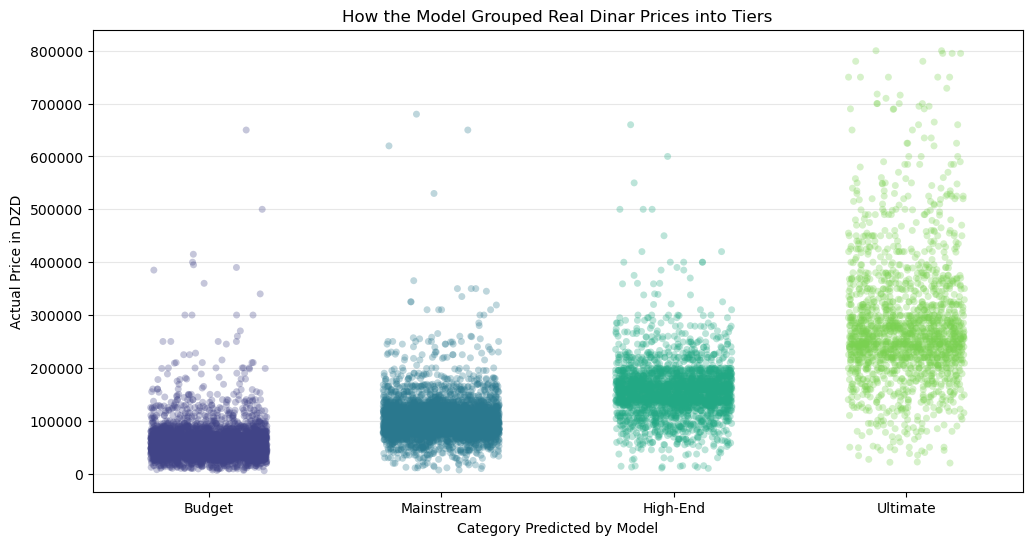

In [8]:
plt.figure(figsize=(12, 6))
order = ['Budget', 'Mainstream', 'High-End', 'Ultimate']

sns.stripplot(data=test, x='PREDICTED_TIER', y='PRICE', 
              order=order, alpha=0.3, jitter=0.25, palette='viridis')

plt.title('How the Model Grouped Real Dinar Prices into Tiers')
plt.ylabel('Actual Price in DZD')
plt.xlabel('Category Predicted by Model')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

##  Official Metrics Report

 OFFICIAL PERFORMANCE: 76.85%
Selected Logic: GINI with Depth 25

--- Deep Report ---
              precision    recall  f1-score   support

      Budget       0.83      0.84      0.84      4310
  Mainstream       0.66      0.69      0.67      2363
    High-End       0.74      0.73      0.74      4249
    Ultimate       0.82      0.78      0.80      1804

    accuracy                           0.77     12726
   macro avg       0.76      0.76      0.76     12726
weighted avg       0.77      0.77      0.77     12726



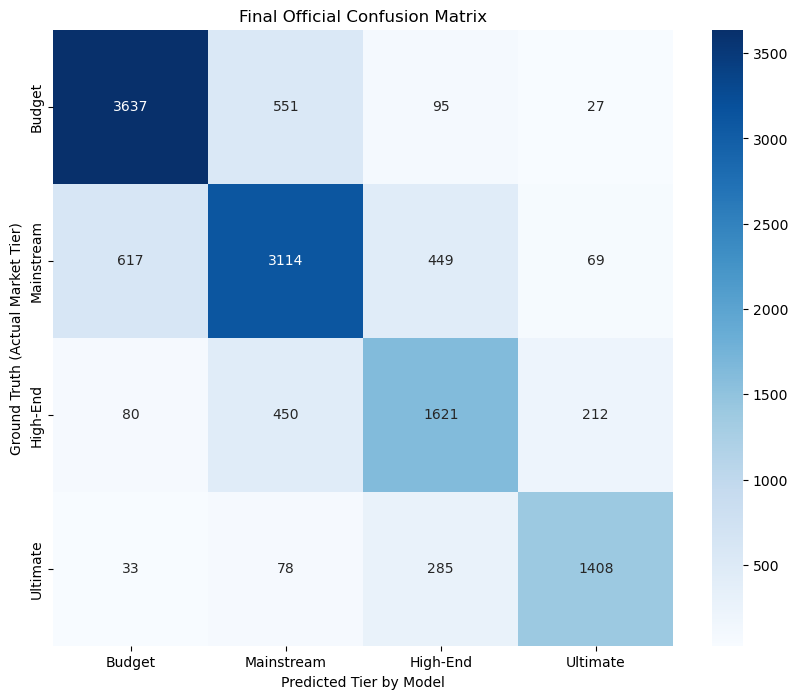

In [10]:
acc = accuracy_score(y_test_tier, y_pred_tier)

print(f" OFFICIAL PERFORMANCE: {acc*100:.2f}%")
print(f"Selected Logic: {clf.criterion.upper()} with Depth {clf.max_depth}")

print("\n--- Deep Report ---")
print(classification_report(y_test_tier, y_pred_tier, target_names=order))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_tier, y_pred_tier, labels=order)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=order, yticklabels=order)
plt.title('Final Official Confusion Matrix')
plt.ylabel('Ground Truth (Actual Market Tier)')
plt.xlabel('Predicted Tier by Model')
plt.show()